# SGTree Systematic Benchmark Summary

This notebook summarizes the manuscript benchmark panels using three fixed contamination scenarios for each of six datasets.

The scenarios are: additional-copy contamination only, singleton-replacement contamination only, and a combined panel containing both contamination types.

## Purpose

- Describe each dataset and scenario before any performance plots are shown.
- Quantify how many wrong markers were introduced per dataset and per genome.
- Distinguish replacement contamination from added-copy contamination.
- Record whether donors are within-group or cross-group.
- Show, for all six datasets and all three scenarios, how cleanup changed RF and how many contaminant markers were removed.

Expected: stable TSV exports under `docs/data/` and a single summary figure under `docs/figures/`.

## Reproducibility Notes

- Run this notebook with the `SGTree (pixi)` kernel.
- The notebook reads benchmark manifests and `summary.tsv` files from `runs/benchmarks/`.
- All exported tables are rewritten on each execution.

Expected: a clean top-to-bottom run with no hidden state.

## Configure Paths and Plot Style

- Define dataset locations and output directories.
- Apply a compact plot style tuned for manuscript figures.

Expected: dataset metadata and plotting defaults loaded in memory.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler

ROOT = Path.cwd().parent
DATA_DIR = ROOT / 'docs' / 'data'
FIG_DIR = ROOT / 'docs' / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = [
    {'dataset_id': 'flavo_small', 'family': 'Flavo', 'size': 'Small', 'benchmark_dir': ROOT / 'runs' / 'benchmarks' / 'flavo20'},
    {'dataset_id': 'flavo_large', 'family': 'Flavo', 'size': 'Large', 'benchmark_dir': ROOT / 'runs' / 'benchmarks' / 'flavo50' / 'benchmark_seed_101'},
    {'dataset_id': 'gamma_small', 'family': 'Gamma', 'size': 'Small', 'benchmark_dir': ROOT / 'runs' / 'benchmarks' / 'gamma20_rprot16'},
    {'dataset_id': 'gamma_large', 'family': 'Gamma', 'size': 'Large', 'benchmark_dir': ROOT / 'runs' / 'benchmarks' / 'gamma50_rprot16'},
    {'dataset_id': 'cross_small', 'family': 'Cross', 'size': 'Small', 'benchmark_dir': ROOT / 'runs' / 'benchmarks' / 'cross_small'},
    {'dataset_id': 'cross_large', 'family': 'Cross', 'size': 'Large', 'benchmark_dir': ROOT / 'runs' / 'benchmarks' / 'cross_large'},
]

SCENARIO_DESCRIPTION = {
    'duplicate_only': 'Added-copy contamination only; no singleton replacement events.',
    'replacement_only': 'Singleton replacement contamination only; no added duplicate copies.',
    'combined': 'Added-copy and singleton-replacement contamination in the same panel.',
}

PALETTE = ['#0b1320', '#2c7da0', '#43aa8b', '#f1c453']
mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'figure.figsize': (12, 10),
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': cycler(color=PALETTE),
    'figure.constrained_layout.use': True,
})

dataset_meta = pd.DataFrame(DATASETS)
dataset_meta

,dataset_id,family,size,benchmark_dir
0,flavo_small,Flavo,Small,/home/fschulz/dev/software/sgtree/runs/benchma...
1,flavo_large,Flavo,Large,/home/fschulz/dev/software/sgtree/runs/benchma...
2,gamma_small,Gamma,Small,/home/fschulz/dev/software/sgtree/runs/benchma...
3,gamma_large,Gamma,Large,/home/fschulz/dev/software/sgtree/runs/benchma...
4,cross_small,Cross,Small,/home/fschulz/dev/software/sgtree/runs/benchma...
5,cross_large,Cross,Large,/home/fschulz/dev/software/sgtree/runs/benchma...


## Load Benchmark Manifests, Event Tables, and Result Summaries

- Load the per-dataset manifest, event tables, per-genome contamination summaries, and the systematic benchmark result table.
- Attach family and size metadata to each row.

Expected: one event-level table, one per-genome table, one scenario-level overview table, and one benchmark-result table.

In [2]:
dataset_rows = []
genome_rows = []
result_rows = []
for item in DATASETS:
    manifest_path = item['benchmark_dir'] / 'benchmark_manifest.json'
    summary_path = item['benchmark_dir'] / 'results' / 'summary.tsv'
    if not manifest_path.exists():
        raise FileNotFoundError(manifest_path)
    if not summary_path.exists():
        raise FileNotFoundError(summary_path)
    manifest = pd.read_json(manifest_path, typ='series')
    results = pd.read_csv(summary_path, sep='	')
    results['dataset_id'] = item['dataset_id']
    results['family'] = item['family']
    results['size'] = item['size']
    results['dataset_label'] = f"{item['family']} {item['size']}"
    result_rows.append(results)
    for scenario in manifest['scenarios']:
        events_path = Path(scenario['events_path'])
        genome_summary_path = Path(scenario['genome_summary_path'])
        if not events_path.is_absolute():
            events_path = ROOT / events_path
        if not genome_summary_path.is_absolute():
            genome_summary_path = ROOT / genome_summary_path
        events = pd.read_csv(events_path, sep='	')
        genome_summary = pd.read_csv(genome_summary_path, sep='	')
        source_scope = 'cross_group_only' if scenario['cross_group_events'] > 0 else 'within_group_only'
        dataset_rows.append({
            'dataset_id': item['dataset_id'],
            'dataset_label': f"{item['family']} {item['size']}",
            'family': item['family'],
            'size': item['size'],
            'scenario': scenario['name'],
            'scenario_description': SCENARIO_DESCRIPTION[scenario['name']],
            'selected_genome_count': len(manifest['selected_genomes']),
            'selected_marker_count': len(manifest['selected_markers']),
            'cross_group_only': bool(manifest.get('cross_group_only', False)),
            'contaminant_markers_added': scenario['contaminant_markers_added'],
            'duplicate_events': scenario['duplicate_events'],
            'replacement_events': scenario['replacement_events'],
            'affected_genomes': scenario['affected_genomes'],
            'mean_contaminants_per_affected_genome': scenario['mean_contaminants_per_affected_genome'],
            'max_contaminants_per_genome': scenario['max_contaminants_per_genome'],
            'within_group_events': scenario['within_group_events'],
            'cross_group_events': scenario['cross_group_events'],
            'source_scope': source_scope,
            'truth_tree_path': str(item['benchmark_dir'] / 'truth_run' / 'tree.nwk'),
            'events_path': scenario['events_path'],
        })
        genome_summary['dataset_id'] = item['dataset_id']
        genome_summary['dataset_label'] = f"{item['family']} {item['size']}"
        genome_summary['scenario'] = scenario['name']
        genome_rows.append(genome_summary)

dataset_overview = pd.DataFrame(dataset_rows).sort_values(['family', 'size', 'scenario'])
genome_overview = pd.concat(genome_rows, ignore_index=True)
benchmark_results = pd.concat(result_rows, ignore_index=True)
benchmark_results['rf_change_label'] = benchmark_results.apply(lambda row: f"{row['initial_tree_rf_norm']:.3f} → {row['tree_rf_norm']:.3f}", axis=1)
benchmark_results['removed_label'] = benchmark_results.apply(lambda row: f"{int(row['contaminant_markers_removed'])}/{int(row['contaminant_markers_added'])}", axis=1)
dataset_overview[['dataset_label', 'scenario', 'scenario_description', 'contaminant_markers_added', 'duplicate_events', 'replacement_events', 'source_scope']].head(18)

,dataset_label,scenario,scenario_description,contaminant_markers_added,duplicate_events,replacement_events,source_scope
17,Cross Large,combined,Added-copy and singleton-replacement contamina...,12,8,4,cross_group_only
15,Cross Large,duplicate_only,Added-copy contamination only; no singleton re...,8,8,0,cross_group_only
16,Cross Large,replacement_only,Singleton replacement contamination only; no a...,4,0,4,cross_group_only
14,Cross Small,combined,Added-copy and singleton-replacement contamina...,12,8,4,cross_group_only
12,Cross Small,duplicate_only,Added-copy contamination only; no singleton re...,8,8,0,cross_group_only
13,Cross Small,replacement_only,Singleton replacement contamination only; no a...,4,0,4,cross_group_only
5,Flavo Large,combined,Added-copy and singleton-replacement contamina...,12,8,4,within_group_only
3,Flavo Large,duplicate_only,Added-copy contamination only; no singleton re...,8,8,0,within_group_only
4,Flavo Large,replacement_only,Singleton replacement contamination only; no a...,4,0,4,within_group_only
2,Flavo Small,combined,Added-copy and singleton-replacement contamina...,12,8,4,within_group_only


## Start with the Dataset and Contamination Summary

- Show, for each dataset and scenario, how many wrong markers were introduced in total.
- Separate added-copy events from singleton-replacement events.
- Report whether donor markers come from within-group or cross-group sources.

Expected: a dataset-level overview table followed by a per-genome contamination table.

In [3]:
display(dataset_overview[['dataset_label', 'scenario', 'scenario_description', 'selected_genome_count', 'selected_marker_count', 'contaminant_markers_added', 'duplicate_events', 'replacement_events', 'affected_genomes', 'mean_contaminants_per_affected_genome', 'max_contaminants_per_genome', 'source_scope']])
display(genome_overview.sort_values(['dataset_label', 'scenario', 'recipient_group', 'recipient_genome']).head(40))

,dataset_label,scenario,scenario_description,selected_genome_count,selected_marker_count,contaminant_markers_added,duplicate_events,replacement_events,affected_genomes,mean_contaminants_per_affected_genome,max_contaminants_per_genome,source_scope
17,Cross Large,combined,Added-copy and singleton-replacement contamina...,79,8,12,8,4,8,1.500000,2,cross_group_only
15,Cross Large,duplicate_only,Added-copy contamination only; no singleton re...,79,8,8,8,0,4,2.000000,2,cross_group_only
16,Cross Large,replacement_only,Singleton replacement contamination only; no a...,79,8,4,0,4,4,1.000000,1,cross_group_only
14,Cross Small,combined,Added-copy and singleton-replacement contamina...,33,6,12,8,4,8,1.500000,2,cross_group_only
12,Cross Small,duplicate_only,Added-copy contamination only; no singleton re...,33,6,8,8,0,4,2.000000,2,cross_group_only
13,Cross Small,replacement_only,Singleton replacement contamination only; no a...,33,6,4,0,4,4,1.000000,1,cross_group_only
5,Flavo Large,combined,Added-copy and singleton-replacement contamina...,45,15,12,8,4,8,1.500000,2,within_group_only
3,Flavo Large,duplicate_only,Added-copy contamination only; no singleton re...,45,15,8,8,0,4,2.000000,2,within_group_only
4,Flavo Large,replacement_only,Singleton replacement contamination only; no a...,45,15,4,0,4,4,1.000000,1,within_group_only
2,Flavo Small,combined,Added-copy and singleton-replacement contamina...,18,10,12,8,4,7,1.714286,2,within_group_only


,recipient_genome,recipient_group,contaminant_markers_added,duplicate_events,replacement_events,within_group_events,cross_group_events,dataset_id,dataset_label,scenario
84,FLAV__GCA_002954325-1,flavo,1,0,1,0,1,cross_large,Cross Large,combined
85,FLAV__GCA_006120725-1,flavo,2,2,0,0,2,cross_large,Cross Large,combined
86,FLAV__GCA_010820555-1,flavo,2,2,0,0,2,cross_large,Cross Large,combined
87,FLAV__GCA_019565505-1,flavo,1,0,1,0,1,cross_large,Cross Large,combined
88,GAMMA__GCA-000147015-1,gamma,2,2,0,0,2,cross_large,Cross Large,combined
89,GAMMA__GCA-000441555-1,gamma,1,0,1,0,1,cross_large,Cross Large,combined
90,GAMMA__GCA-000478685-1,gamma,2,2,0,0,2,cross_large,Cross Large,combined
91,GAMMA__GCA-018260315-1,gamma,1,0,1,0,1,cross_large,Cross Large,combined
76,FLAV__GCA_006120725-1,flavo,2,2,0,0,2,cross_large,Cross Large,duplicate_only
77,FLAV__GCA_010820555-1,flavo,2,2,0,0,2,cross_large,Cross Large,duplicate_only


## Summarize Tree Comparisons and Removal Counts

- Pair each scenario with its clean truth tree, initial contaminated tree, and cleaned tree.
- Report initial RF, final RF, RF delta, and contaminant markers removed out of contaminant markers added.

Expected: one compact result table with exactly three rows per dataset.

In [4]:
result_table = benchmark_results[['dataset_label', 'scenario', 'cleanup_profile', 'truth_tree_path', 'initial_tree_path', 'final_tree_path', 'initial_tree_rf_norm', 'tree_rf_norm', 'tree_rf_delta', 'contaminant_markers_removed', 'contaminant_markers_added', 'contaminant_markers_removed_fraction', 'duplicate_contaminant_removed', 'duplicate_events', 'replacement_contaminant_removed', 'replacement_events']]
result_table = result_table.sort_values(['dataset_label', 'scenario'])
display(result_table)

,dataset_label,scenario,cleanup_profile,truth_tree_path,initial_tree_path,final_tree_path,initial_tree_rf_norm,tree_rf_norm,tree_rf_delta,contaminant_markers_removed,contaminant_markers_added,contaminant_markers_removed_fraction,duplicate_contaminant_removed,duplicate_events,replacement_contaminant_removed,replacement_events
17,Cross Large,combined,duplicate_plus_singles_neighbor,runs/benchmarks/cross_large/truth_run/tree.nwk,runs/benchmarks/cross_large/results/combined__...,runs/benchmarks/cross_large/results/combined__...,0.144737,0.065789,0.078947,10,12,0.833333,8,8,2,4
15,Cross Large,duplicate_only,duplicate_cleanup,runs/benchmarks/cross_large/truth_run/tree.nwk,runs/benchmarks/cross_large/results/duplicate_...,runs/benchmarks/cross_large/results/duplicate_...,0.144737,0.000000,0.144737,8,8,1.000000,8,8,0,0
16,Cross Large,replacement_only,singles_neighbor,runs/benchmarks/cross_large/truth_run/tree.nwk,runs/benchmarks/cross_large/results/replacemen...,runs/benchmarks/cross_large/results/replacemen...,0.197368,0.108108,0.089260,4,4,1.000000,0,0,4,4
14,Cross Small,combined,duplicate_plus_singles_neighbor,runs/benchmarks/cross_small/truth_run/tree.nwk,runs/benchmarks/cross_small/results/combined__...,runs/benchmarks/cross_small/results/combined__...,0.566667,0.400000,0.166667,5,12,0.416667,3,8,2,4
12,Cross Small,duplicate_only,duplicate_cleanup,runs/benchmarks/cross_small/truth_run/tree.nwk,runs/benchmarks/cross_small/results/duplicate_...,runs/benchmarks/cross_small/results/duplicate_...,0.333333,0.333333,0.000000,3,8,0.375000,3,8,0,0
13,Cross Small,replacement_only,singles_neighbor,runs/benchmarks/cross_small/truth_run/tree.nwk,runs/benchmarks/cross_small/results/replacemen...,runs/benchmarks/cross_small/results/replacemen...,0.366667,0.172414,0.194253,4,4,1.000000,0,0,4,4
5,Flavo Large,combined,duplicate_plus_singles_neighbor,runs/benchmarks/flavo50/benchmark_seed_101/tru...,runs/benchmarks/flavo50/benchmark_seed_101/res...,runs/benchmarks/flavo50/benchmark_seed_101/res...,0.000000,0.023810,-0.023810,4,12,0.333333,0,8,4,4
3,Flavo Large,duplicate_only,duplicate_cleanup,runs/benchmarks/flavo50/benchmark_seed_101/tru...,runs/benchmarks/flavo50/benchmark_seed_101/res...,runs/benchmarks/flavo50/benchmark_seed_101/res...,0.047619,0.000000,0.047619,4,8,0.500000,4,8,0,0
4,Flavo Large,replacement_only,singles_neighbor,runs/benchmarks/flavo50/benchmark_seed_101/tru...,runs/benchmarks/flavo50/benchmark_seed_101/res...,runs/benchmarks/flavo50/benchmark_seed_101/res...,0.023810,0.047619,-0.023810,4,4,1.000000,0,0,4,4
2,Flavo Small,combined,duplicate_plus_singles_neighbor,runs/benchmarks/flavo20/truth_run/tree.nwk,runs/benchmarks/flavo20/results/combined__dupl...,runs/benchmarks/flavo20/results/combined__dupl...,0.200000,0.000000,0.200000,6,12,0.500000,2,8,4,4


## Render the Systematic Benchmark Figure

- For each scenario, plot the initial contaminated-tree RF and the cleaned-tree RF for all six datasets.
- Overlay the fraction of contaminant markers removed so the topology change and cleanup performance are shown together.

Expected: one three-panel figure saved under `docs/figures/benchmark_summary.*`.

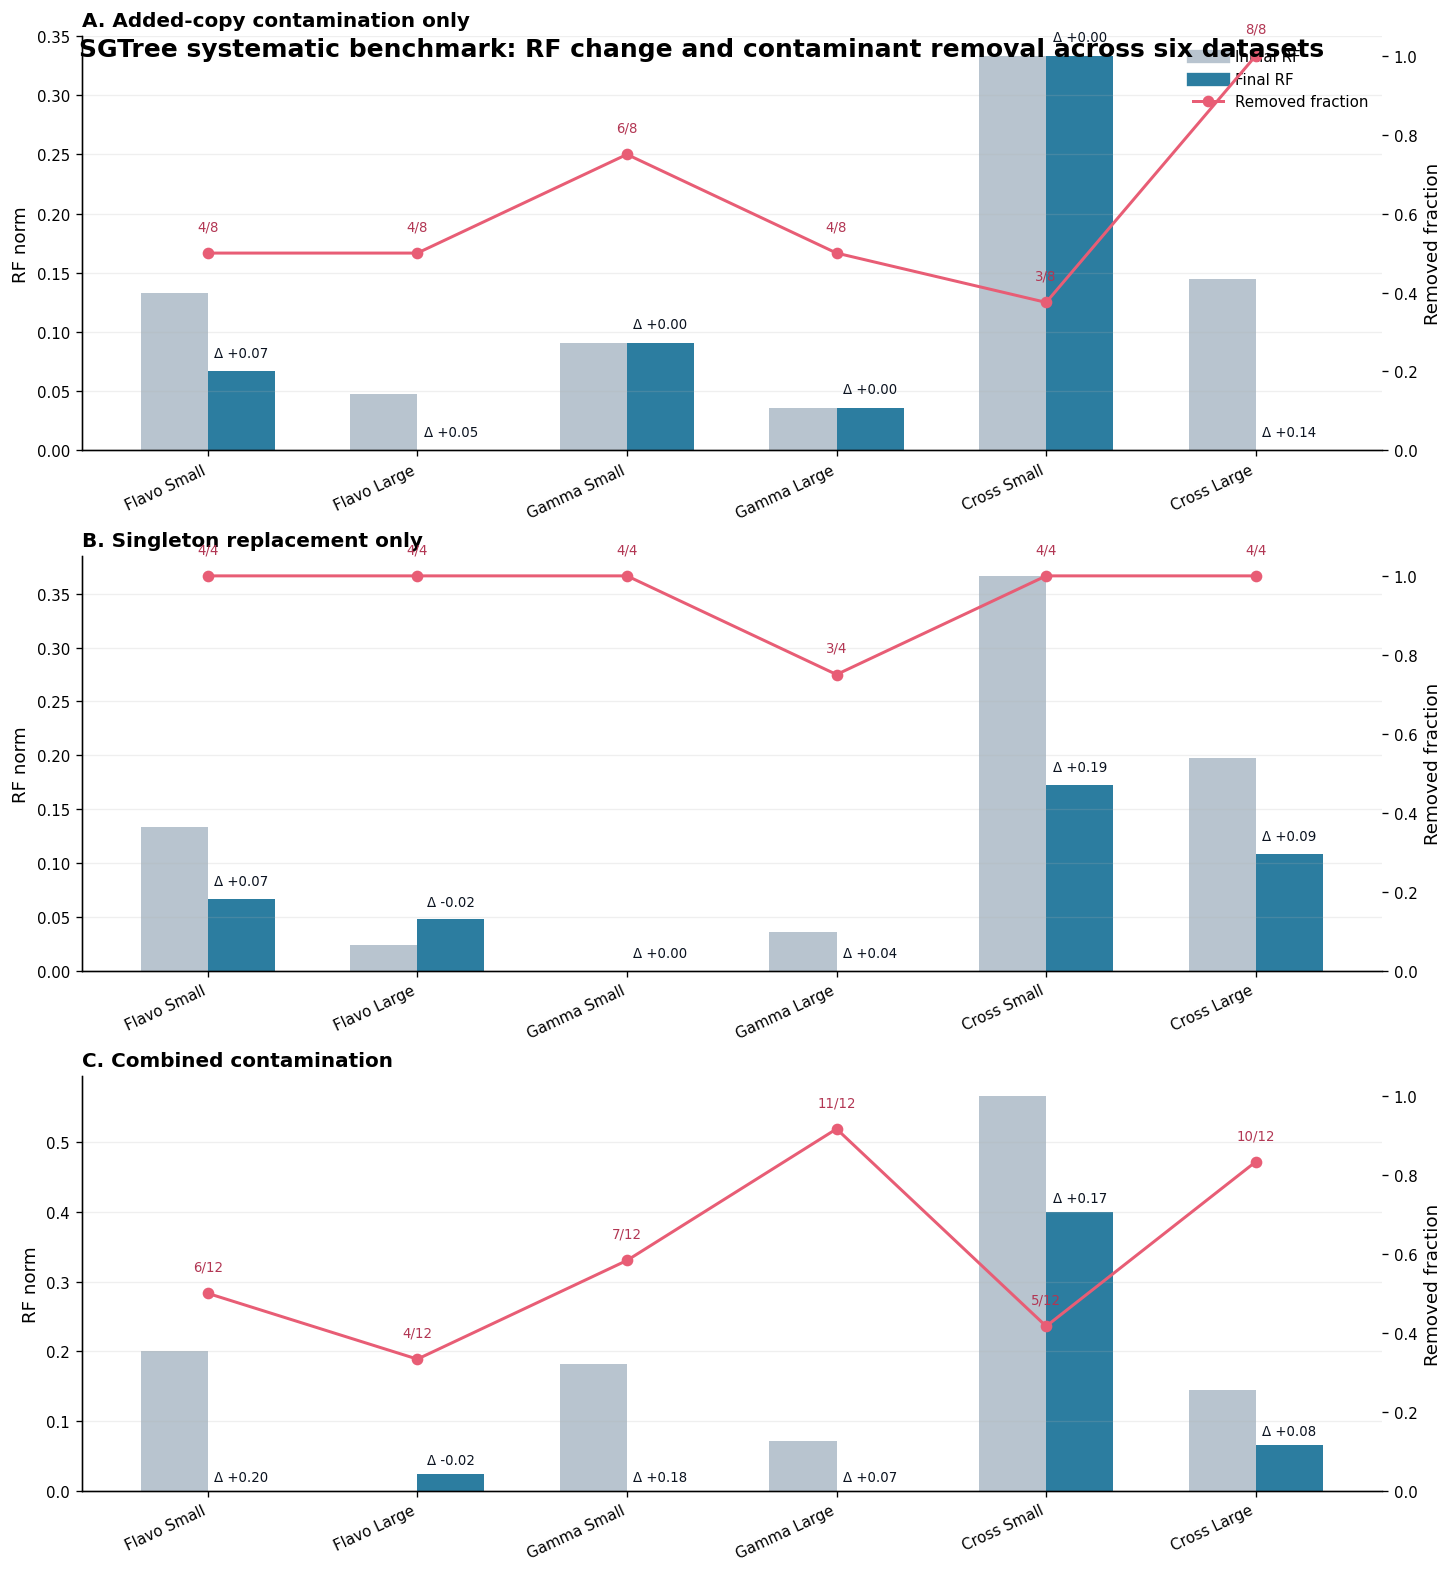

In [5]:
dataset_order = ['Flavo Small', 'Flavo Large', 'Gamma Small', 'Gamma Large', 'Cross Small', 'Cross Large']
scenario_order = ['duplicate_only', 'replacement_only', 'combined']
scenario_titles = {
    'duplicate_only': 'A. Added-copy contamination only',
    'replacement_only': 'B. Singleton replacement only',
    'combined': 'C. Combined contamination',
}
plot_df = benchmark_results.copy()
plot_df['dataset_label'] = pd.Categorical(plot_df['dataset_label'], dataset_order, ordered=True)
plot_df = plot_df.sort_values(['scenario', 'dataset_label'])

fig, axes = plt.subplots(3, 1, figsize=(12, 13), sharex=False)
for ax, scenario in zip(axes, scenario_order, strict=True):
    sub = plot_df[plot_df['scenario'] == scenario].sort_values('dataset_label')
    x = np.arange(len(sub))
    width = 0.32
    ax.bar(x - width / 2, sub['initial_tree_rf_norm'], width=width, color='#b8c4cf', label='Initial RF')
    ax.bar(x + width / 2, sub['tree_rf_norm'], width=width, color='#2c7da0', label='Final RF')
    ax.set_ylabel('RF norm')
    ax.set_title(scenario_titles[scenario], loc='left', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['dataset_label'], rotation=25, ha='right')
    ax.grid(axis='y', alpha=0.2)
    ax2 = ax.twinx()
    ax2.plot(x, sub['contaminant_markers_removed_fraction'], color='#e85d75', marker='o', linewidth=1.8, label='Removed fraction')
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Removed fraction')
    for xi, row in zip(x, sub.itertuples(index=False), strict=True):
        ax.text(xi + width / 2, row.tree_rf_norm + 0.01, f"Δ {row.tree_rf_delta:+.2f}", ha='center', va='bottom', fontsize=8, color='#0b1320')
        ax2.text(xi, row.contaminant_markers_removed_fraction + 0.05, f"{int(row.contaminant_markers_removed)}/{int(row.contaminant_markers_added)}", ha='center', va='bottom', fontsize=8, color='#b23653')

legend_handles = [
    plt.Line2D([0], [0], color='#b8c4cf', linewidth=8),
    plt.Line2D([0], [0], color='#2c7da0', linewidth=8),
    plt.Line2D([0], [0], color='#e85d75', marker='o', linewidth=1.8),
]
legend_labels = ['Initial RF', 'Final RF', 'Removed fraction']
axes[0].legend(legend_handles, legend_labels, loc='upper right', frameon=False)
fig.suptitle('SGTree systematic benchmark: RF change and contaminant removal across six datasets', fontsize=15, fontweight='bold', x=0.05, y=0.98, ha='left')
fig.savefig(FIG_DIR / 'benchmark_summary.png', bbox_inches='tight', pad_inches=0.08)
fig.savefig(FIG_DIR / 'benchmark_summary.svg', bbox_inches='tight', pad_inches=0.08)
plt.show()

## Export Stable Tables for the Manuscript

- Export the dataset/scenario overview, the per-genome contamination counts, and the final benchmark result table.
- These exported TSVs are what the benchmark writeup and manuscript should cite.

Expected: stable data products under `docs/data/`.

In [6]:
dataset_overview.to_csv(DATA_DIR / 'benchmark_dataset_overview.tsv', sep='	', index=False)
genome_overview.to_csv(DATA_DIR / 'benchmark_genome_contamination.tsv', sep='	', index=False)
benchmark_results.sort_values(['dataset_label', 'scenario']).to_csv(DATA_DIR / 'benchmark_summary_all.tsv', sep='	', index=False)
display((DATA_DIR / 'benchmark_dataset_overview.tsv').name)
display((DATA_DIR / 'benchmark_genome_contamination.tsv').name)
display((DATA_DIR / 'benchmark_summary_all.tsv').name)

'benchmark_dataset_overview.tsv'

'benchmark_genome_contamination.tsv'

'benchmark_summary_all.tsv'

## Conclusions

- The benchmark outputs now match the manuscript-oriented systematic design: duplicate-only, replacement-only, and combined contamination.
- The key quantities to report are initial RF, final RF, RF delta, and contaminant markers removed out of contaminant markers added.

Expected: the docs and manuscript can now be rewritten directly from the exported tables and figure.